In [1]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor

import category_encoders as ce
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, plot_importance
from catboost import CatBoostClassifier
import time
import mlflow
from mlflow.models import infer_signature
from mlflow import MlflowClient
import optuna

/home/kroman/Documents/GIT Code Usecases/usecase_churn_telco/.venv_churn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#| include: false
import warnings
warnings.filterwarnings("ignore")

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)

## Raw data

Let’s begin by exploring and analyzing the data:

In [3]:
df = pd.read_csv("../data/external/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape
df.head()

(7043, 21)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
df["Churn"] = df["Churn"].replace({'Yes' : 1, 'No' : 0,}).astype(int)
df["Churn"].value_counts(dropna=False, normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

The dataset contains 7,043 customers, with an average tenure of 32.4 months and average monthly charges of 64.8, approximately 73.5% of customers did not churn. Most features are categorical, and `TotalCharges` appears to be stored as a non-numeric variable and should therefore be converted before modeling.

## Visualisations

The following visualisations analyze the characteristics and behavior of customers who churn, with a particular focus on demographic, billing, and tenure-related patterns.

In [7]:
InteractiveShell.ast_node_interactivity = "last"

In [8]:
group_Churn = pd.DataFrame(df.groupby("gender")["Churn"].sum()).reset_index()

fig = px.bar(
    group_Churn,
    x="gender",
    y="Churn",
    title="Number of Churned Customers by Gender",
    color=None,
    labels={
        "gender": "Gender",
        "Churn": "Number of Churned Customers"
    },
    text_auto=True
)

fig.update_layout(
    template="plotly_white",
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    font=dict(
        family="Inter",
        color="#81a8b6"
    ),
    xaxis_title="Gender",
    yaxis_title="Number of Churned Customers"
)

fig.update_traces(textposition="outside")
fig.show()

The number of churned customers is almost evenly distributed between genders, with no substantial difference observed.

In [9]:
df_copy = df.copy()
df_copy["MonthlyCharges_range"] = pd.cut(
    df["MonthlyCharges"],
    bins=[-np.inf, 30, 50, 70, 90, np.inf],
    labels=[
        "Less than 30",
        "30 to less than 50",
        "50 to less than 70",
        "70 to less than 90",
        "90 and above"
    ],
    right=False
)

monthly_churn_plot = df_copy.groupby(["MonthlyCharges_range", "Churn"], observed=False).size().reset_index(name="Number_of_customers")
monthly_churn_plot["Churn"] = monthly_churn_plot["Churn"].astype(str)

fig = px.bar(
    monthly_churn_plot,
    x="MonthlyCharges_range",
    y="Number_of_customers",
    color="Churn",
    barmode="stack",
    text_auto=True,
    title="Churn Distribution by Monthly Charge Range",
    category_orders={
        "MonthlyCharges_range": [
            "Moins de 30",
            "30 à moins de 50",
            "50 à moins de 70",
            "70 à moins de 90",
            "90 et plus"
        ],
        "Churn_status": ["Non churn", "Churn"]
    },
    labels={
        "MonthlyCharges_range": "Monthly Charges",
        "Number_of_customers": "Number of Customers",
        "Churn_status": "Customer Status"
    }
)

fig.update_layout(
    template="plotly_white",
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    font=dict(
        family="Inter",
        color="#81A8B6"
    ),
    legend_title_text="Status",
    xaxis_title="Monthly Charge Range",
    yaxis_title="Number of Customers"
)

fig.update_traces(textposition="inside")
fig.show()

The churn rate is lowest among customers paying less than 30 per month (9.8%) and peaks among those paying between 70 and less than 90 (38.0%).

In [10]:
df_copy["Tenure_range"] = pd.cut(
    df_copy["tenure"],
    bins=[-1, 6, 12, 24, 48, 60, np.inf],
    labels=[
        "0 to 6 months",
        "7 to 12 months",
        "13 to 24 months",
        "25 to 48 months",
        "49 to 60 months",
        "61 months and above"
    ]
)

tenure_churn_plot = df_copy.groupby(["Tenure_range", "Churn"], observed=False).size().reset_index(name="Number_of_customers")
tenure_churn_plot["Churn"] = tenure_churn_plot["Churn"].astype(str)

fig = px.bar(
    tenure_churn_plot,
    x="Tenure_range",
    y="Number_of_customers",
    color="Churn",
    barmode="stack",
    text_auto=True,
    title="Churn Distribution by Customer Tenure",
    category_orders={
        "Tenure_range": [
            "0 to 6 months",
            "7 to 12 months",
            "13 to 24 months",
            "25 to 48 months",
            "49 to 60 months",
            "61 months and above"
        ],
        "Churn_status": ["Non churn", "Churn"]
    },
    labels={
        "Tenure_range": "Customer Tenure",
        "Number_of_customers": "Number of Customers",
        "Churn_status": "Customer Status"
    }
)

fig.update_layout(
    template="plotly_white",
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    font=dict(
        family="Inter",
        color="#81A8B6"
    ),
    legend_title_text="Status",
    xaxis_title="Customer Tenure",
    yaxis_title="Number of Customers"
)

fig.update_traces(textposition="inside")
fig.show()

The churn rate decreases sharply as customer tenure increases, falling from 52.9% during the first six months to only 6.1% among customers with a tenure of 61 months or more.

In [11]:
InteractiveShell.ast_node_interactivity = "all"

## Cleaning

The `TotalCharges` column is converted to a numeric data type, while invalid or empty values are replaced with missing values (`NaN`).

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

The `customerID` column is removed because it is a unique identifier and does not provide useful information for predicting customer churn.

In [13]:
df = df.drop(columns="customerID")
df.shape

(7043, 20)

The correlations between the numerical features and customer churn are calculated and visualized to identify the variables most strongly associated with churn.

In [14]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix[["Churn"]].drop(index="Churn").sort_values(by="Churn", ascending=False)

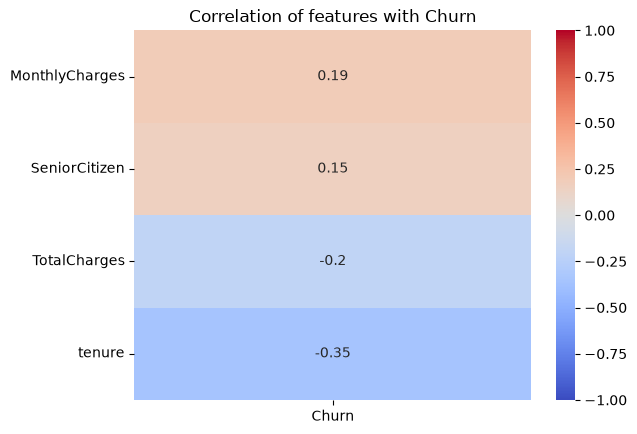

In [15]:
plt.figure()
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of features with Churn")
plt.show();

Churn is negatively correlated with tenure, while monthly charges and senior-citizen status show weak positive correlations.

Creation of a binary variable equal to 1 when the customer has no internet service, and 0 otherwise:

In [16]:
internet_service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

df["No_internet_service"] = (df[internet_service_cols].eq("No internet service").all(axis=1).astype(int))
df["No_internet_service"].value_counts()

No_internet_service
0    5517
1    1526
Name: count, dtype: int64

Creation of a column that represents the total number of internet-related services subscribed to by each customer:

In [17]:
df["Internet_services_count"] = (df[internet_service_cols].eq("Yes").sum(axis=1).astype("int8"))
df["Internet_services_count"].value_counts()

Internet_services_count
0    2219
3    1118
2    1033
1     966
4     852
5     571
6     284
Name: count, dtype: int64

The "No internet service" category is then replaced with "No" to standardize the values and avoid redundant information.

In [18]:
df[internet_service_cols] = df[internet_service_cols].replace("No internet service", "No")

In [19]:
df.isna().sum().sum() # No missions values

np.int64(11)

In [20]:
df.shape
df.head()

(7043, 22)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,No_internet_service,Internet_services_count
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,0,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0,0


## Encodage

Categorical columns:

In [21]:
cat_cols = df.select_dtypes(include='str').columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

The data is divided into features `X` and the target `y`, then split into 80% training and 20% testing sets while preserving the churn class distribution.

In [22]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
X_train.shape
y_train.shape

X_test.shape
y_test.shape

(5634, 21)

(5634,)

(1409, 21)

(1409,)

The categorical features are transformed using Weight of Evidence encoding fitted only on the training data to prevent data leakage. The same learned mapping is applied to the test set, and the encoded columns are renamed with the `_woe` suffix.

In [24]:
woe_encoder = ce.WOEEncoder(cols = cat_cols)

X_train_woe = woe_encoder.fit_transform(X_train, y_train)
X_test_woe = woe_encoder.transform(X_test)

rename_columns = {col: f"{col}_woe" for col in cat_cols}

X_train_woe = X_train_woe.rename(columns=rename_columns)
X_test_woe = X_test_woe.rename(columns=rename_columns)

In [25]:
X_train_woe.shape
X_train_woe.dtypes

(5634, 21)

gender_woe                 float64
SeniorCitizen                int64
Partner_woe                float64
Dependents_woe             float64
tenure                       int64
PhoneService_woe           float64
MultipleLines_woe          float64
InternetService_woe        float64
OnlineSecurity_woe         float64
OnlineBackup_woe           float64
DeviceProtection_woe       float64
TechSupport_woe            float64
StreamingTV_woe            float64
StreamingMovies_woe        float64
Contract_woe               float64
PaperlessBilling_woe       float64
PaymentMethod_woe          float64
MonthlyCharges             float64
TotalCharges               float64
No_internet_service          int64
Internet_services_count       int8
dtype: object

In [26]:
woe_encoder.mapping

{'gender': gender
  1   -0.004977
  2    0.005022
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'Partner': Partner
  1    0.299455
  2   -0.373863
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'Dependents': Dependents
  1    0.234231
  2   -0.699275
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'PhoneService': PhoneService
  1   -0.121960
  2    0.013046
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'MultipleLines': MultipleLines
  1   -0.121960
  2   -0.078659
  3    0.112569
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'InternetService': InternetService
  1   -0.450768
  2    0.698499
  3   -1.521204
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'OnlineSecurity': OnlineSecurity
  1    0.238207
  2   -0.759999
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'OnlineBackup': OnlineBackup
  1    0.132926
  2   -0.270702
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'DeviceProtection': DeviceProtection
  1   -0.201000
  2    0.098905
 -1    0.000000
 -2    0

In [27]:
X_train_woe.gender_woe.value_counts()

gender_woe
-0.004977    2833
 0.005022    2801
Name: count, dtype: int64

In [28]:
X_test_woe.gender_woe.value_counts()

gender_woe
-0.004977    722
 0.005022    687
Name: count, dtype: int64

## Multicolinearity (VIF)

Infinite and missing values are removed before calculating the Variance Inflation Factor (VIF) for each feature. The results are sorted in descending order to identify variables with the highest multicollinearity.

In [29]:
X = X_train_woe.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
X.shape

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
vif_data

(5626, 21)

,feature,VIF
0,StreamingTV_woe,1.000800e+15
1,OnlineBackup_woe,1.000800e+15
2,DeviceProtection_woe,1.000800e+15
3,TechSupport_woe,1.000800e+15
4,OnlineSecurity_woe,1.000800e+15
5,Internet_services_count,1.000800e+15
6,StreamingMovies_woe,1.000800e+15
7,MonthlyCharges,8.635752e+02
8,InternetService_woe,3.422117e+02
9,PhoneService_woe,3.171579e+01


The extremely high VIF values reveal severe multicollinearity, particularly between `Internet_services_count` and the WOE-encoded internet service features. However, multicollinearity is not a major concern for tree-based models such as XGBoost, although it may affect the interpretation of feature importance.


## Machine Learning models and experiment tracking with MLFlow

The Random Forest, XGBoost, LightGBM, and CatBoost models are evaluated using these features.

In [30]:
X_train_woe.shape
X_test_woe.shape

y_train.shape
y_test.shape

(5634, 21)

(1409, 21)

(5634,)

(1409,)

Three decision thresholds (0.30, 0.35, and 0.40) are evaluated to convert predicted churn probabilities into class labels. Since the target variable is imbalanced, testing thresholds below the default value of 0.50 helps identify an appropriate trade-off between recall and precision for the minority churn class.

In [31]:
THRESHOLD = [0.30, 0.35, 0.40]

We need to evaluate each model using five-fold stratified cross-validation, while fitting the WOE encoder and calculating class weights exclusively on each training fold to prevent data leakage. It returns fold-level metrics, their mean and standard deviation, and out-of-fold predicted probabilities.

In [32]:
def evaluate_model_cv(model, model_name, X, y, cat_cols, threshold=0.30, n_splits=5):
    X_cv = X.reset_index(drop=True).copy()
    y_cv = pd.Series(y).reset_index(drop=True)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_proba = np.zeros(len(y_cv))
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
        X_fold_train = X_cv.iloc[train_idx].copy()
        X_fold_val = X_cv.iloc[val_idx].copy()
        y_fold_train = y_cv.iloc[train_idx]
        y_fold_val = y_cv.iloc[val_idx]

        fold_cat_cols = [col for col in cat_cols if col in X_fold_train.columns]

        encoder = ce.WOEEncoder(cols=fold_cat_cols, handle_unknown="value", handle_missing="value")
        X_fold_train = encoder.fit_transform(X_fold_train, y_fold_train)
        X_fold_val = encoder.transform(X_fold_val)

        rename_mapping = {col: f"{col}_woe" for col in fold_cat_cols}
        X_fold_train = X_fold_train.rename(columns=rename_mapping)
        X_fold_val = X_fold_val.rename(columns=rename_mapping)

        X_fold_train = X_fold_train.replace([np.inf, -np.inf], np.nan)
        X_fold_val = X_fold_val.replace([np.inf, -np.inf], np.nan)

        train_medians = X_fold_train.median()
        
        X_fold_train = X_fold_train.fillna(train_medians)
        X_fold_val = X_fold_val.fillna(train_medians)

        scale_pos_weight = ((y_fold_train == 0).sum() / (y_fold_train == 1).sum())
        sample_weight = np.where(y_fold_train == 1, scale_pos_weight, 1.0)

        fold_model = clone(model) # new model for each fold
        fold_model.fit(X_fold_train, y_fold_train, sample_weight=sample_weight)

        fold_proba = fold_model.predict_proba(X_fold_val)[:, 1]
        fold_pred = (fold_proba >= threshold).astype(int)
        oof_proba[val_idx] = fold_proba

        fold_results.append({
            "fold": fold,
            "roc_auc": roc_auc_score(y_fold_val, fold_proba),
            "pr_auc": average_precision_score(y_fold_val, fold_proba),
            "precision": precision_score(y_fold_val, fold_pred, zero_division=0),
            "recall": recall_score(y_fold_val, fold_pred, zero_division=0),
            "f1": f1_score(y_fold_val, fold_pred, zero_division=0)
        })

    cv_results = pd.DataFrame(fold_results)
    metric_cols = ["roc_auc", "pr_auc", "precision", "recall", "f1"]
    summary = (cv_results[metric_cols].agg(["mean", "std"]).T.round(3))

    return cv_results, summary, oof_proba

With the evaluation framework in place, the next step is to maintain a clear and reproducible record of every experiment. MLflow is configured as a central tracking workspace where model configurations, decision thresholds and performance metrics can be consistently compared throughout the model-selection process.

In [32]:
MLFLOW_EXPERIMENT_NAME = "usecase_telco_churn_thresholds"
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())

<Experiment: artifact_location='mlflow-artifacts:/7', creation_time=1789993206610, effective_trace_archival_retention=None, experiment_id='7', last_update_time=1789993206610, lifecycle_stage='active', name='usecase_telco_churn_thresholds', tags={}, trace_location=None, workspace='default'>

Tracking URI: http://127.0.0.1:5000


In [34]:
def evaluate_and_log_model(model, model_name, model_params, X_train, y_train, cat_cols, threshold):
    
    with mlflow.start_run(run_name=model_name):
        start_time = time.time()

        results, summary, oof_proba = evaluate_model_cv(
            model=model,
            model_name=model_name,
            X=X_train,
            y=y_train,
            cat_cols=cat_cols,
            threshold=threshold
        )

        cv_time = time.time() - start_time
        
        mlflow.log_params({
            "model": model_name,
            "n_splits": 5,
            "threshold": threshold,
            "encoding": "WOE",
            **model_params
        })

        mlflow.log_metrics({
            "cv_roc_auc_mean": float(summary.loc["roc_auc", "mean"]),
            "cv_roc_auc_std": float(summary.loc["roc_auc", "std"]),
            "cv_pr_auc_mean": float(summary.loc["pr_auc", "mean"]),
            "cv_pr_auc_std": float(summary.loc["pr_auc", "std"]),
            "cv_recall_mean": float(summary.loc["recall", "mean"]),
            "cv_precision_mean": float(summary.loc["precision", "mean"]),
            "cv_f1_mean": float(summary.loc["f1", "mean"]),
            "cv_time_seconds": cv_time
        })

    return results, summary, oof_proba

### Random Forest

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

for treshold in THRESHOLD:
    rf_results, rf_summary, rf_oof = evaluate_and_log_model(
        model=rf_model,
        model_name=f"Random Forest - {treshold}",
        model_params={
            "n_estimators": 300,
            "random_state": 42
        },
        X_train=X_train,
        y_train=y_train,
        cat_cols=cat_cols,
        threshold=treshold
    )

🏃 View run Random Forest - 0.3 at: http://127.0.0.1:5000/#/experiments/7/runs/45306916ab254dc9b67a9cea01d45a74
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run Random Forest - 0.35 at: http://127.0.0.1:5000/#/experiments/7/runs/c508b3c645c6425fae68cdff6b5e8f43
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run Random Forest - 0.4 at: http://127.0.0.1:5000/#/experiments/7/runs/11beb7d75ca54766832bea769a27566b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


### XGBoost

In [36]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

for treshold in THRESHOLD:
    xgb_results, xgb_summary, xgb_oof = evaluate_and_log_model(
        model=xgb_model,
        model_name=f"XGBoost - {treshold}",
        model_params={
            "n_estimators": 300,
            "learning_rate": 0.05,
            "max_depth": 6,
            "random_state": 42
        },
        X_train=X_train,
        y_train=y_train,
        cat_cols=cat_cols,
        threshold=treshold
    )

🏃 View run XGBoost - 0.3 at: http://127.0.0.1:5000/#/experiments/7/runs/80e589c8a4f4430c9bdf2e21653b105d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run XGBoost - 0.35 at: http://127.0.0.1:5000/#/experiments/7/runs/4e03ff2265ac4aa99aa34659c0ac65e3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run XGBoost - 0.4 at: http://127.0.0.1:5000/#/experiments/7/runs/3f5dd4b8d0bc415bab9dd6937f979d8d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


### LightGBM

In [37]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

for treshold in THRESHOLD:
    lgbm_results, lgbm_summary, lgbm_oof = evaluate_and_log_model(
        model=lgbm_model,
        model_name=f"LightGBM - {treshold}",
        model_params={
            "n_estimators": 300,
            "learning_rate": 0.05,
            "random_state": 42
        },
        X_train=X_train,
        y_train=y_train,
        cat_cols=cat_cols,
        threshold=treshold
    )

🏃 View run LightGBM - 0.3 at: http://127.0.0.1:5000/#/experiments/7/runs/26deb103aa3349499a0916367f2574b2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run LightGBM - 0.35 at: http://127.0.0.1:5000/#/experiments/7/runs/ebe7ae5332bd418eb30b85765d386a0f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run LightGBM - 0.4 at: http://127.0.0.1:5000/#/experiments/7/runs/3c41c607e926475dba2a2828ec1a927f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


### CatBoost

In [38]:
catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

for treshold in THRESHOLD:
    catboost_results, catboost_summary, catboost_oof = (
        evaluate_and_log_model(
            model=catboost_model,
            model_name=f"CatBoost - {treshold}",
            model_params={
                "iterations": 300,
                "learning_rate": 0.05,
                "depth": 6,
                "random_seed": 42
            },
            X_train=X_train,
            y_train=y_train,
            cat_cols=cat_cols,
            threshold=treshold
        )
    )

🏃 View run CatBoost - 0.3 at: http://127.0.0.1:5000/#/experiments/7/runs/20dd014e72b645c882ea935892f97097
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run CatBoost - 0.35 at: http://127.0.0.1:5000/#/experiments/7/runs/56c5d80102224a6489f11f6f88040999
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run CatBoost - 0.4 at: http://127.0.0.1:5000/#/experiments/7/runs/3f04c78a4d59458599ff58769bdb47d2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


This screenshot summarizes the experiment runs tracked on the local MLflow server, which can be launched using the `mlflow server` command. ROC-AUC and PR-AUC were used to compare the models’ overall discrimination ability independently of the decision threshold, with particular emphasis on PR-AUC because the target variable is imbalanced. Precision, recall, and F1-score were then used to compare the candidate thresholds. Based on these cross-validation results, CatBoost with a 0.40 threshold and LightGBM with a 0.35 threshold were selected for hyperparameter optimization. The best optimized model will subsequently be evaluated on the held-out test set and integrated into the final churn prediction pipeline.

![image](static/MLflow_metrics_models_thresholds.png)

### Hyperparameter Tuning with Optuna

After selecting CatBoost and LightGBM as the strongest candidates, their hyperparameters are optimized using Optuna. Optuna is an automated optimization framework that efficiently explores the hyperparameter search space to identify the configuration that maximizes cross-validated recall at the selected threshold.

#### CatBoost hyperparameter optimization with a 0.40 decision threshold

In [33]:
THRESHOLD_CATBOOST  = 0.4

In [34]:
X_opt = X_train.reset_index(drop=True).copy()
y_opt = pd.Series(y_train).reset_index(drop=True)

cv_optuna = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_catboost(trial, threshold=THRESHOLD_CATBOOST):

    bootstrap_type = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"])

    params = {
        "iterations": trial.suggest_int("iterations", 300, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "bootstrap_type": bootstrap_type,
        "loss_function": "Logloss",
        "random_seed": 42,
        "thread_count": -1,
        "verbose": False,
        "allow_writing_files": False
    }

    if bootstrap_type == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 5.0)
    else:
        params["subsample"] = trial.suggest_float("subsample", 0.6, 1.0)

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv_optuna.split(X_opt, y_opt), start=1):
        X_fold_train = X_opt.iloc[train_idx].copy()
        X_fold_val = X_opt.iloc[val_idx].copy()

        y_fold_train = y_opt.iloc[train_idx]
        y_fold_val = y_opt.iloc[val_idx]

        fold_cat_cols = [col for col in cat_cols if col in X_fold_train.columns]

        encoder = ce.WOEEncoder(cols=fold_cat_cols, handle_unknown="value", handle_missing="value")

        X_fold_train = encoder.fit_transform(X_fold_train, y_fold_train)
        X_fold_val = encoder.transform(X_fold_val)

        X_fold_train = X_fold_train.replace([np.inf, -np.inf], np.nan)
        X_fold_val = X_fold_val.replace([np.inf, -np.inf], np.nan)

        train_medians = X_fold_train.median()

        X_fold_train = X_fold_train.fillna(train_medians)
        X_fold_val = X_fold_val.fillna(train_medians)

        scale_pos_weight = ((y_fold_train == 0).sum() / (y_fold_train == 1).sum())

        sample_weight = np.where(y_fold_train == 1, scale_pos_weight, 1.0)

        model = CatBoostClassifier(**params)
        model.fit(X_fold_train, y_fold_train, sample_weight=sample_weight)
        
        fold_proba = model.predict_proba(X_fold_val)[:, 1]
        fold_pred = (fold_proba >= threshold).astype(int)
        fold_score = recall_score(y_fold_val, fold_pred, pos_label=1, zero_division=0)
        fold_scores.append(fold_score)
        trial.report(np.mean(fold_scores), step=fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

A dedicated MLflow experiment is configured to track the optimization runs, selected hyperparameters, evaluation metrics and optimized model artifacts.

In [35]:
MLFLOW_EXPERIMENT_NAME = "usecase_telco_churn_optimization"
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

<Experiment: artifact_location='mlflow-artifacts:/8', creation_time=1789993271687, effective_trace_archival_retention=None, experiment_id='8', last_update_time=1789993271687, lifecycle_stage='active', name='usecase_telco_churn_optimization', tags={}, trace_location=None, workspace='default'>

In [36]:
with mlflow.start_run(run_name="CatBoost_Optuna_Optimization_0.40"):

    study_catboost = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
    )

    study_catboost.optimize(objective_catboost, n_trials=30, show_progress_bar=True)

    mlflow.log_params({
        f"best_{key}": value
        for key, value in study_catboost.best_params.items()
    })

    mlflow.log_params({
        "model": "CatBoost",
        "optimization": "Optuna",
        "n_trials": 30,
        "n_splits": 5,
        "encoding": "WOE",
        "optimized_metric": "Recall",
        "decision_threshold": THRESHOLD_CATBOOST
    })

    mlflow.log_metric("cv_train_recall", float(study_catboost.best_value))

    best_catboost_params = {
    **study_catboost.best_params,
    "loss_function": "Logloss",
    "random_seed": 42,
    "thread_count": -1,
    "verbose": False,
    "allow_writing_files": False
    }

    catboost_optimized = CatBoostClassifier(**best_catboost_params)

    scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum())
    sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)

    catboost_optimized.fit(X_train_woe, y_train, sample_weight=sample_weight)

    test_proba = catboost_optimized.predict_proba(X_test_woe)[:, 1]
    test_pred_cat = (test_proba >= THRESHOLD_CATBOOST).astype(int)

    mlflow.log_metric("test_recall", recall_score(y_test, test_pred_cat))
    mlflow.log_metric("test_precision", precision_score(y_test, test_pred_cat))

    X_example = X_train_woe.head(20)
    y_example = catboost_optimized.predict(X_example)

    signature = infer_signature(X_example, y_example)

    mlflow.catboost.log_model(cb_model=catboost_optimized,
        name="catboost_optimized_model",
        signature=signature,
        input_example=X_train_woe.head(5),
        metadata={
            "decision_threshold": THRESHOLD_CATBOOST,
            "encoding": "WOE"
        })

[I 2026-09-21 15:41:44,673] A new study created in memory with name: no-name-63cd3d00-b6bd-4ca1-9066-691ce23aa677
Best trial: 0. Best value: 0.814047:   3%|▎         | 1/30 [00:04<02:00,  4.17s/it]

[I 2026-09-21 15:41:48,846] Trial 0 finished with value: 0.814046822742475 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 800, 'learning_rate': 0.060099747183803134, 'depth': 4, 'l2_leaf_reg': 1.5957084694148351, 'random_strength': 0.11616722433639892, 'border_count': 226, 'subsample': 0.8404460046972835}. Best is trial 0 with value: 0.814046822742475.


Best trial: 0. Best value: 0.814047:   7%|▋         | 2/30 [00:12<03:13,  6.89s/it]

[I 2026-09-21 15:41:57,646] Trial 1 finished with value: 0.7625418060200668 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 1000, 'learning_rate': 0.12106896936002161, 'depth': 5, 'l2_leaf_reg': 1.7240892195821529, 'random_strength': 0.36680901970686763, 'border_count': 100, 'bagging_temperature': 2.6237821581611893}. Best is trial 0 with value: 0.814046822742475.


Best trial: 2. Best value: 0.854849:  10%|█         | 3/30 [00:19<03:04,  6.85s/it]

[I 2026-09-21 15:42:04,444] Trial 2 finished with value: 0.8548494983277592 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 700, 'learning_rate': 0.01518747922672247, 'depth': 5, 'l2_leaf_reg': 2.9967309097101573, 'random_strength': 0.9121399684340719, 'border_count': 207, 'bagging_temperature': 0.9983689107917987}. Best is trial 2 with value: 0.8548494983277592.


Best trial: 2. Best value: 0.854849:  13%|█▎        | 4/30 [00:22<02:16,  5.24s/it]

[I 2026-09-21 15:42:07,203] Trial 3 finished with value: 0.8515050167224081 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.061721159481070736, 'depth': 4, 'l2_leaf_reg': 1.2151617026673374, 'random_strength': 1.8977710745066665, 'border_count': 248, 'subsample': 0.9233589392465844}. Best is trial 2 with value: 0.8548494983277592.


Best trial: 2. Best value: 0.854849:  17%|█▋        | 5/30 [00:29<02:23,  5.74s/it]

[I 2026-09-21 15:42:13,839] Trial 4 finished with value: 0.8441471571906355 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 800, 'learning_rate': 0.03738105868191797, 'depth': 4, 'l2_leaf_reg': 4.407984038169241, 'random_strength': 0.06877704223043679, 'border_count': 235, 'bagging_temperature': 1.2938999080000846}. Best is trial 2 with value: 0.8548494983277592.


Best trial: 2. Best value: 0.854849:  20%|██        | 6/30 [00:34<02:17,  5.75s/it]

[I 2026-09-21 15:42:19,594] Trial 5 finished with value: 0.8468227424749164 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 700, 'learning_rate': 0.05143828405076928, 'depth': 4, 'l2_leaf_reg': 18.258230439200236, 'random_strength': 1.550265646722229, 'border_count': 242, 'bagging_temperature': 4.474136752138244}. Best is trial 2 with value: 0.8548494983277592.


Best trial: 6. Best value: 0.877592:  23%|██▎       | 7/30 [00:37<01:50,  4.80s/it]

[I 2026-09-21 15:42:22,456] Trial 6 finished with value: 0.8775919732441471 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.017987863473362915, 'depth': 4, 'l2_leaf_reg': 2.6501137707458966, 'random_strength': 0.777354579378964, 'border_count': 92, 'subsample': 0.9314950036607718}. Best is trial 6 with value: 0.8775919732441471.


Best trial: 6. Best value: 0.877592:  27%|██▋       | 8/30 [00:42<01:47,  4.90s/it]

[I 2026-09-21 15:42:27,555] Trial 7 pruned. 


Best trial: 6. Best value: 0.877592:  30%|███       | 9/30 [00:47<01:38,  4.68s/it]

[I 2026-09-21 15:42:31,750] Trial 8 pruned. 


Best trial: 6. Best value: 0.877592:  33%|███▎      | 10/30 [00:50<01:23,  4.18s/it]

[I 2026-09-21 15:42:34,812] Trial 9 finished with value: 0.865551839464883 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 300, 'learning_rate': 0.02538617845650057, 'depth': 5, 'l2_leaf_reg': 8.89691667259267, 'random_strength': 1.2751149427104262, 'border_count': 230, 'bagging_temperature': 2.3610746258097466}. Best is trial 6 with value: 0.8775919732441471.


Best trial: 6. Best value: 0.877592:  37%|███▋      | 11/30 [00:55<01:27,  4.58s/it]

[I 2026-09-21 15:42:40,315] Trial 10 finished with value: 0.8521739130434781 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 800, 'learning_rate': 0.021136427700111548, 'depth': 4, 'l2_leaf_reg': 1.9918840402334448, 'random_strength': 0.28948174178103825, 'border_count': 106, 'subsample': 0.6138103737325284}. Best is trial 6 with value: 0.8775919732441471.


Best trial: 6. Best value: 0.877592:  40%|████      | 12/30 [00:58<01:14,  4.11s/it]

[I 2026-09-21 15:42:43,352] Trial 11 finished with value: 0.8628762541806021 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 300, 'learning_rate': 0.028241983469903417, 'depth': 5, 'l2_leaf_reg': 12.716675430878848, 'random_strength': 1.163986492987457, 'border_count': 170, 'bagging_temperature': 4.961813327301686}. Best is trial 6 with value: 0.8775919732441471.


Best trial: 6. Best value: 0.877592:  43%|████▎     | 13/30 [01:01<01:02,  3.66s/it]

[I 2026-09-21 15:42:45,983] Trial 12 finished with value: 0.8695652173913043 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.02322300408069596, 'depth': 4, 'l2_leaf_reg': 4.612201251381928, 'random_strength': 0.6405062533956184, 'border_count': 239, 'subsample': 0.7049085515253415}. Best is trial 6 with value: 0.8775919732441471.


Best trial: 13. Best value: 0.881605:  47%|████▋     | 14/30 [01:03<00:52,  3.29s/it]

[I 2026-09-21 15:42:48,422] Trial 13 finished with value: 0.8816053511705686 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.013155344488377156, 'depth': 4, 'l2_leaf_reg': 1.6247603492573954, 'random_strength': 1.089384975525689, 'border_count': 54, 'subsample': 0.7086672832839681}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 13. Best value: 0.881605:  50%|█████     | 15/30 [01:06<00:49,  3.28s/it]

[I 2026-09-21 15:42:51,671] Trial 14 finished with value: 0.8735785953177257 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 400, 'learning_rate': 0.018913968427794255, 'depth': 4, 'l2_leaf_reg': 2.516071602060436, 'random_strength': 1.091024579838937, 'border_count': 67, 'subsample': 0.7877675668240075}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 13. Best value: 0.881605:  53%|█████▎    | 16/30 [01:09<00:44,  3.17s/it]

[I 2026-09-21 15:42:54,571] Trial 15 finished with value: 0.8709030100334447 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.019748773808370618, 'depth': 4, 'l2_leaf_reg': 1.5620580493569394, 'random_strength': 0.48827381100188205, 'border_count': 117, 'subsample': 0.9956883827401696}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 13. Best value: 0.881605:  57%|█████▋    | 17/30 [01:13<00:43,  3.37s/it]

[I 2026-09-21 15:42:58,423] Trial 16 finished with value: 0.8729096989966555 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 500, 'learning_rate': 0.011054858285790304, 'depth': 4, 'l2_leaf_reg': 4.20519457459067, 'random_strength': 0.3583905586263386, 'border_count': 77, 'subsample': 0.7888439430024857}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 13. Best value: 0.881605:  60%|██████    | 18/30 [01:16<00:38,  3.22s/it]

[I 2026-09-21 15:43:01,284] Trial 17 finished with value: 0.8802675585284281 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.012451522241465647, 'depth': 5, 'l2_leaf_reg': 3.537029049627512, 'random_strength': 1.2404016784593308, 'border_count': 106, 'subsample': 0.6019420729727811}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 13. Best value: 0.881605:  63%|██████▎   | 19/30 [01:19<00:34,  3.11s/it]

[I 2026-09-21 15:43:04,135] Trial 18 finished with value: 0.8802675585284281 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.013216399163683192, 'depth': 5, 'l2_leaf_reg': 1.8743750120432774, 'random_strength': 1.773327401345239, 'border_count': 70, 'subsample': 0.6193391141307083}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 13. Best value: 0.881605:  67%|██████▋   | 20/30 [01:21<00:29,  2.92s/it]

[I 2026-09-21 15:43:06,609] Trial 19 pruned. 


Best trial: 13. Best value: 0.881605:  70%|███████   | 21/30 [01:24<00:25,  2.89s/it]

[I 2026-09-21 15:43:09,427] Trial 20 finished with value: 0.8795986622073579 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.010955072029529922, 'depth': 5, 'l2_leaf_reg': 5.862163474133441, 'random_strength': 1.2077474197169915, 'border_count': 128, 'subsample': 0.7139663995237504}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 13. Best value: 0.881605:  73%|███████▎  | 22/30 [01:27<00:23,  2.89s/it]

[I 2026-09-21 15:43:12,323] Trial 21 finished with value: 0.8802675585284281 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.01234262614164506, 'depth': 5, 'l2_leaf_reg': 1.9872482632856543, 'random_strength': 1.673869746459916, 'border_count': 90, 'subsample': 0.60368170131389}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 13. Best value: 0.881605:  77%|███████▋  | 23/30 [01:31<00:21,  3.09s/it]

[I 2026-09-21 15:43:15,884] Trial 22 finished with value: 0.8755852842809364 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 400, 'learning_rate': 0.012368835063219466, 'depth': 5, 'l2_leaf_reg': 4.5970559999612215, 'random_strength': 1.6884088237427803, 'border_count': 103, 'subsample': 0.6393783999957466}. Best is trial 13 with value: 0.8816053511705686.


Best trial: 23. Best value: 0.882274:  80%|████████  | 24/30 [01:33<00:17,  2.96s/it]

[I 2026-09-21 15:43:18,531] Trial 23 finished with value: 0.8822742474916387 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.013074741342067903, 'depth': 4, 'l2_leaf_reg': 2.133063743007336, 'random_strength': 1.9693411697496441, 'border_count': 40, 'subsample': 0.6641069674960026}. Best is trial 23 with value: 0.8822742474916387.


Best trial: 23. Best value: 0.882274:  83%|████████▎ | 25/30 [01:37<00:15,  3.12s/it]

[I 2026-09-21 15:43:22,033] Trial 24 finished with value: 0.8749163879598661 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 400, 'learning_rate': 0.0158412637491453, 'depth': 5, 'l2_leaf_reg': 8.23873887250887, 'random_strength': 1.5988561150875207, 'border_count': 61, 'subsample': 0.6775065182920693}. Best is trial 23 with value: 0.8822742474916387.


Best trial: 23. Best value: 0.882274:  87%|████████▋ | 26/30 [01:40<00:12,  3.07s/it]

[I 2026-09-21 15:43:24,970] Trial 25 finished with value: 0.8755852842809364 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.016707406113233476, 'depth': 5, 'l2_leaf_reg': 4.8373844697401, 'random_strength': 0.862110114251925, 'border_count': 33, 'subsample': 0.7481902087733296}. Best is trial 23 with value: 0.8822742474916387.


Best trial: 23. Best value: 0.882274:  90%|█████████ | 27/30 [01:42<00:08,  2.95s/it]

[I 2026-09-21 15:43:27,647] Trial 26 finished with value: 0.8769230769230768 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.025611212958427814, 'depth': 4, 'l2_leaf_reg': 2.4681426476480173, 'random_strength': 1.8344773585801915, 'border_count': 64, 'subsample': 0.6652571898165668}. Best is trial 23 with value: 0.8822742474916387.


Best trial: 27. Best value: 0.882943:  93%|█████████▎| 28/30 [01:45<00:05,  2.80s/it]

[I 2026-09-21 15:43:30,086] Trial 27 finished with value: 0.882943143812709 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 300, 'learning_rate': 0.01023452151825699, 'depth': 4, 'l2_leaf_reg': 1.2817843470441894, 'random_strength': 1.3173414934140384, 'border_count': 79, 'subsample': 0.7421574015909039}. Best is trial 27 with value: 0.882943143812709.


Best trial: 27. Best value: 0.882943:  97%|█████████▋| 29/30 [01:48<00:02,  2.97s/it]

[I 2026-09-21 15:43:33,449] Trial 28 pruned. 


Best trial: 27. Best value: 0.882943: 100%|██████████| 30/30 [01:51<00:00,  3.72s/it]


[I 2026-09-21 15:43:36,330] Trial 29 pruned. 


CatBoostClassifier(allow_writing_files=False, bootstrap_type='Bernoulli', border_count=79, depth=4, iterations=300, l2_leaf_reg=1.2817843470441894, learning_rate=0.01023452151825699, loss_function='Logloss', random_seed=42, random_strength=1.3173414934140384, subsample=0.7421574015909039, verbose=False)

🏃 View run CatBoost_Optuna_Optimization_0.40 at: http://127.0.0.1:5000/#/experiments/8/runs/c8b150e98658406fad60e306857c5c52
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/8


#### LightGBM hyperparameter optimization with a 0.35 decision threshold

In [37]:
THRESHOLD_LIGHTGBM  = 0.35

In [38]:
X_opt = X_train.reset_index(drop=True).copy()
y_opt = pd.Series(y_train).reset_index(drop=True)

cv_optuna = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_lightgbm(trial, threshold=THRESHOLD_LIGHTGBM):
    max_depth = trial.suggest_int("max_depth", 3, 8)
    max_num_leaves = min(127, (2 ** max_depth) - 1)

    params = {
        "boosting_type": "gbdt",
        "objective": "binary",
        "metric": "binary_logloss",
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 7, max_num_leaves),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.60, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
        "deterministic": True,
        "force_col_wise": True
    }

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv_optuna.split(X_opt, y_opt), start=1):
        X_fold_train = X_opt.iloc[train_idx].copy()
        X_fold_val = X_opt.iloc[val_idx].copy()

        y_fold_train = y_opt.iloc[train_idx]
        y_fold_val = y_opt.iloc[val_idx]

        fold_cat_cols = [col for col in cat_cols if col in X_fold_train.columns]

        encoder = ce.WOEEncoder(
            cols=fold_cat_cols,
            handle_unknown="value",
            handle_missing="value"
        )

        X_fold_train = encoder.fit_transform(X_fold_train, y_fold_train)
        X_fold_val = encoder.transform(X_fold_val)

        X_fold_train = X_fold_train.replace([np.inf, -np.inf], np.nan)
        X_fold_val = X_fold_val.replace([np.inf, -np.inf], np.nan)

        train_medians = (X_fold_train.median().fillna(0))

        X_fold_train = (X_fold_train.fillna(train_medians).fillna(0))
        X_fold_val = (X_fold_val.fillna(train_medians).fillna(0))

        remaining_cat_cols = (X_fold_train.select_dtypes(exclude=np.number).columns.tolist())

        if remaining_cat_cols:
            raise ValueError("Non-numeric columns remaining after WOE: {remaining_cat_cols}")

        fold_scale_pos_weight = ((y_fold_train == 0).sum() / (y_fold_train == 1).sum())
        sample_weight = np.where(y_fold_train.to_numpy() == 1, fold_scale_pos_weight, 1.0)

        model = LGBMClassifier(**params)
        model.fit(X_fold_train, y_fold_train, sample_weight=sample_weight)

        fold_proba = model.predict_proba(X_fold_val)[:, 1]
        fold_pred = (fold_proba >= threshold).astype(int)
        fold_recall = recall_score(y_fold_val, fold_pred, pos_label=1, zero_division=0)
        fold_scores.append(fold_recall)
        trial.report(float(np.mean(fold_scores)), step=fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

In [39]:
with mlflow.start_run(run_name="LightGBM_Optuna_Optimization_0.35"):

    study_lightgbm = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
    )

    study_lightgbm.optimize(objective_lightgbm, n_trials=30, show_progress_bar=True)

    mlflow.log_params({
        f"best_{key}": value
        for key, value in study_lightgbm.best_params.items()
    })

    mlflow.log_params({
        "model": "LightGBM",
        "optimization": "Optuna",
        "n_trials": 30,
        "n_splits": 5,
        "encoding": "WOE",
        "optimized_metric": "Recall",
        "decision_threshold": THRESHOLD_LIGHTGBM
    })

    mlflow.log_metric("cv_train_recall", float(study_lightgbm.best_value))

    best_lightgbm_params = {
        **study_lightgbm.best_params,
        "boosting_type": "gbdt",
        "objective": "binary",
        "metric": "binary_logloss",
        "subsample_freq": 1,
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
        "deterministic": True,
        "force_col_wise": True
    }

    lightgbm_optimized = LGBMClassifier(**best_lightgbm_params)

    scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum())
    sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)

    lightgbm_optimized.fit(X_train_woe, y_train, sample_weight=sample_weight)

    test_proba = lightgbm_optimized.predict_proba(X_test_woe)[:, 1]
    test_pred_lgbm = (test_proba >= THRESHOLD_LIGHTGBM).astype(int)

    mlflow.log_metric("test_recall", recall_score(y_test, test_pred_lgbm))
    mlflow.log_metric("test_precision", precision_score(y_test, test_pred_lgbm))

    X_example = X_train_woe.head(20)
    y_example = lightgbm_optimized.predict(X_example)

    signature = infer_signature(X_example, y_example)

    mlflow.lightgbm.log_model(lgb_model=lightgbm_optimized,
        name="lightgbm_optimized_model",
        signature=signature,
        input_example=X_train_woe.head(5),
        metadata={
            "decision_threshold": THRESHOLD_LIGHTGBM,
            "encoding": "WOE"
        })

[I 2026-09-21 15:43:39,654] A new study created in memory with name: no-name-63c5c5da-65aa-4a7a-91f8-dca746ff16e2
Best trial: 0. Best value: 0.779933:   3%|▎         | 1/30 [00:10<05:00, 10.36s/it]

[I 2026-09-21 15:43:50,010] Trial 0 finished with value: 0.779933110367893 and parameters: {'max_depth': 5, 'n_estimators': 1000, 'learning_rate': 0.08960785365368121, 'num_leaves': 21, 'min_child_samples': 24, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'min_split_gain': 0.7080725777960455}. Best is trial 0 with value: 0.779933110367893.


Best trial: 1. Best value: 0.814716:   7%|▋         | 2/30 [00:16<03:46,  8.07s/it]

[I 2026-09-21 15:43:56,485] Trial 1 finished with value: 0.8147157190635452 and parameters: {'max_depth': 3, 'n_estimators': 1000, 'learning_rate': 0.12106896936002161, 'num_leaves': 7, 'min_child_samples': 29, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323, 'min_split_gain': 0.43194501864211576}. Best is trial 1 with value: 0.8147157190635452.


Best trial: 2. Best value: 0.885619:  10%|█         | 3/30 [00:23<03:14,  7.21s/it]

[I 2026-09-21 15:44:02,662] Trial 2 finished with value: 0.8856187290969899 and parameters: {'max_depth': 4, 'n_estimators': 700, 'learning_rate': 0.01518747922672247, 'num_leaves': 9, 'min_child_samples': 43, 'subsample': 0.7824279936868144, 'colsample_bytree': 0.9140703845572055, 'reg_alpha': 6.267062696005991e-07, 'reg_lambda': 0.00042472707398058225, 'min_split_gain': 0.5924145688620425}. Best is trial 2 with value: 0.8856187290969899.


Best trial: 3. Best value: 0.889632:  13%|█▎        | 4/30 [00:27<02:44,  6.32s/it]

[I 2026-09-21 15:44:07,631] Trial 3 finished with value: 0.8896321070234114 and parameters: {'max_depth': 3, 'n_estimators': 700, 'learning_rate': 0.016666983286066417, 'num_leaves': 7, 'min_child_samples': 15, 'subsample': 0.9795542149013333, 'colsample_bytree': 0.9862528132298237, 'reg_alpha': 0.18861495878553936, 'reg_lambda': 5.514725787121931e-06, 'min_split_gain': 0.09767211400638387}. Best is trial 3 with value: 0.8896321070234114.


Best trial: 3. Best value: 0.889632:  17%|█▋        | 5/30 [00:44<04:13, 10.14s/it]

[I 2026-09-21 15:44:24,534] Trial 4 finished with value: 0.8381270903010034 and parameters: {'max_depth': 7, 'n_estimators': 600, 'learning_rate': 0.014413697528610409, 'num_leaves': 66, 'min_child_samples': 13, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.7035119926400067, 'reg_alpha': 0.009176996354542699, 'reg_lambda': 6.388511557344611e-06, 'min_split_gain': 0.5200680211778108}. Best is trial 3 with value: 0.8896321070234114.


Best trial: 3. Best value: 0.889632:  20%|██        | 6/30 [00:48<03:07,  7.80s/it]

[I 2026-09-21 15:44:27,801] Trial 5 pruned. 


Best trial: 3. Best value: 0.889632:  23%|██▎       | 7/30 [00:52<02:34,  6.74s/it]

[I 2026-09-21 15:44:32,340] Trial 6 finished with value: 0.8882943143812708 and parameters: {'max_depth': 3, 'n_estimators': 500, 'learning_rate': 0.03203913722293047, 'num_leaves': 7, 'min_child_samples': 34, 'subsample': 0.9314950036607718, 'colsample_bytree': 0.7427013306774357, 'reg_alpha': 3.376063348877853e-06, 'reg_lambda': 0.0007660634613082914, 'min_split_gain': 0.14092422497476265}. Best is trial 3 with value: 0.8896321070234114.


Best trial: 3. Best value: 0.889632:  27%|██▋       | 8/30 [00:55<02:02,  5.59s/it]

[I 2026-09-21 15:44:35,461] Trial 7 pruned. 


Best trial: 8. Best value: 0.896321:  30%|███       | 9/30 [01:00<01:50,  5.28s/it]

[I 2026-09-21 15:44:40,060] Trial 8 finished with value: 0.8963210702341137 and parameters: {'max_depth': 3, 'n_estimators': 500, 'learning_rate': 0.014149761574941432, 'num_leaves': 7, 'min_child_samples': 88, 'subsample': 0.8493192507310232, 'colsample_bytree': 0.7323592099410596, 'reg_alpha': 3.732717755563729e-08, 'reg_lambda': 6.292756043818863e-06, 'min_split_gain': 0.32518332202674705}. Best is trial 8 with value: 0.8963210702341137.


Best trial: 8. Best value: 0.896321:  33%|███▎      | 10/30 [01:04<01:36,  4.84s/it]

[I 2026-09-21 15:44:43,930] Trial 9 pruned. 


Best trial: 8. Best value: 0.896321:  37%|███▋      | 11/30 [01:08<01:30,  4.76s/it]

[I 2026-09-21 15:44:48,512] Trial 10 pruned. 


Best trial: 8. Best value: 0.896321:  40%|████      | 12/30 [01:12<01:16,  4.27s/it]

[I 2026-09-21 15:44:51,664] Trial 11 pruned. 


Best trial: 8. Best value: 0.896321:  43%|████▎     | 13/30 [01:22<01:42,  6.02s/it]

[I 2026-09-21 15:45:01,719] Trial 12 finished with value: 0.8876254180602008 and parameters: {'max_depth': 4, 'n_estimators': 600, 'learning_rate': 0.014553670570519395, 'num_leaves': 9, 'min_child_samples': 51, 'subsample': 0.8649944706691359, 'colsample_bytree': 0.7353488143007486, 'reg_alpha': 8.307174897042788, 'reg_lambda': 1.8601262627125267e-07, 'min_split_gain': 0.1511440430904881}. Best is trial 8 with value: 0.8963210702341137.


Best trial: 8. Best value: 0.896321:  47%|████▋     | 14/30 [01:28<01:39,  6.20s/it]

[I 2026-09-21 15:45:08,329] Trial 13 pruned. 


Best trial: 8. Best value: 0.896321:  50%|█████     | 15/30 [01:32<01:20,  5.37s/it]

[I 2026-09-21 15:45:11,776] Trial 14 pruned. 


Best trial: 15. Best value: 0.900334:  53%|█████▎    | 16/30 [01:37<01:14,  5.33s/it]

[I 2026-09-21 15:45:17,002] Trial 15 finished with value: 0.9003344481605351 and parameters: {'max_depth': 3, 'n_estimators': 500, 'learning_rate': 0.010525445506625436, 'num_leaves': 7, 'min_child_samples': 61, 'subsample': 0.8576716066544122, 'colsample_bytree': 0.7321909849491282, 'reg_alpha': 3.7023573597955307e-06, 'reg_lambda': 0.0007870106972458583, 'min_split_gain': 0.25597615547381275}. Best is trial 15 with value: 0.9003344481605351.


Best trial: 15. Best value: 0.900334:  57%|█████▋    | 17/30 [01:42<01:09,  5.35s/it]

[I 2026-09-21 15:45:22,416] Trial 16 finished with value: 0.8989966555183946 and parameters: {'max_depth': 3, 'n_estimators': 500, 'learning_rate': 0.011277362834871733, 'num_leaves': 7, 'min_child_samples': 66, 'subsample': 0.8687167151148477, 'colsample_bytree': 0.8082287277191423, 'reg_alpha': 1.3420648764928595e-05, 'reg_lambda': 4.5058634882684864e-08, 'min_split_gain': 0.35980912617811067}. Best is trial 15 with value: 0.9003344481605351.


Best trial: 17. Best value: 0.901003:  60%|██████    | 18/30 [01:47<01:02,  5.18s/it]

[I 2026-09-21 15:45:27,199] Trial 17 finished with value: 0.9010033444816052 and parameters: {'max_depth': 3, 'n_estimators': 400, 'learning_rate': 0.011721486062746677, 'num_leaves': 7, 'min_child_samples': 63, 'subsample': 0.7570334989869528, 'colsample_bytree': 0.8143642447291745, 'reg_alpha': 6.083853522161001e-07, 'reg_lambda': 5.570224249045669e-06, 'min_split_gain': 0.3844184933710749}. Best is trial 17 with value: 0.9010033444816052.


Best trial: 17. Best value: 0.901003:  63%|██████▎   | 19/30 [01:50<00:51,  4.65s/it]

[I 2026-09-21 15:45:30,598] Trial 18 finished with value: 0.8956521739130434 and parameters: {'max_depth': 3, 'n_estimators': 400, 'learning_rate': 0.01910360043241848, 'num_leaves': 7, 'min_child_samples': 51, 'subsample': 0.8446336828387107, 'colsample_bytree': 0.7559963104861595, 'reg_alpha': 1.6916148154205614e-05, 'reg_lambda': 0.00025633844104302274, 'min_split_gain': 0.5537811612746835}. Best is trial 17 with value: 0.9010033444816052.


Best trial: 17. Best value: 0.901003:  67%|██████▋   | 20/30 [01:54<00:42,  4.28s/it]

[I 2026-09-21 15:45:34,010] Trial 19 pruned. 


Best trial: 17. Best value: 0.901003:  70%|███████   | 21/30 [01:59<00:40,  4.46s/it]

[I 2026-09-21 15:45:38,892] Trial 20 finished with value: 0.8949832775919733 and parameters: {'max_depth': 4, 'n_estimators': 400, 'learning_rate': 0.01003796126722002, 'num_leaves': 11, 'min_child_samples': 69, 'subsample': 0.7718415205956236, 'colsample_bytree': 0.7874237650541553, 'reg_alpha': 6.191699964302811e-06, 'reg_lambda': 4.5501494025474985e-05, 'min_split_gain': 0.23935885293898268}. Best is trial 17 with value: 0.9010033444816052.


Best trial: 21. Best value: 0.901672:  73%|███████▎  | 22/30 [02:02<00:33,  4.20s/it]

[I 2026-09-21 15:45:42,502] Trial 21 finished with value: 0.9016722408026755 and parameters: {'max_depth': 3, 'n_estimators': 400, 'learning_rate': 0.011081402876546886, 'num_leaves': 7, 'min_child_samples': 55, 'subsample': 0.7849883434658963, 'colsample_bytree': 0.7366193675358297, 'reg_alpha': 6.742205411385297e-07, 'reg_lambda': 0.014118859569597134, 'min_split_gain': 0.429771131705046}. Best is trial 21 with value: 0.9016722408026755.


Best trial: 21. Best value: 0.901672:  77%|███████▋  | 23/30 [02:05<00:26,  3.73s/it]

[I 2026-09-21 15:45:45,140] Trial 22 finished with value: 0.8956521739130434 and parameters: {'max_depth': 3, 'n_estimators': 300, 'learning_rate': 0.020831680199704595, 'num_leaves': 7, 'min_child_samples': 56, 'subsample': 0.7251970984896787, 'colsample_bytree': 0.784736465707326, 'reg_alpha': 9.666726649318779e-06, 'reg_lambda': 0.006508924226199449, 'min_split_gain': 0.4031866029393348}. Best is trial 21 with value: 0.9016722408026755.


Best trial: 21. Best value: 0.901672:  80%|████████  | 24/30 [02:09<00:22,  3.68s/it]

[I 2026-09-21 15:45:48,685] Trial 23 pruned. 


Best trial: 21. Best value: 0.901672:  83%|████████▎ | 25/30 [02:14<00:21,  4.33s/it]

[I 2026-09-21 15:45:54,537] Trial 24 pruned. 


Best trial: 21. Best value: 0.901672:  87%|████████▋ | 26/30 [02:18<00:16,  4.07s/it]

[I 2026-09-21 15:45:57,992] Trial 25 finished with value: 0.8989966555183946 and parameters: {'max_depth': 3, 'n_estimators': 400, 'learning_rate': 0.013238116083857027, 'num_leaves': 7, 'min_child_samples': 51, 'subsample': 0.7389409172519197, 'colsample_bytree': 0.8588441247877668, 'reg_alpha': 4.4219925981302705e-07, 'reg_lambda': 0.018274575731767908, 'min_split_gain': 0.6031274959498893}. Best is trial 21 with value: 0.9016722408026755.


Best trial: 21. Best value: 0.901672:  90%|█████████ | 27/30 [02:22<00:12,  4.16s/it]

[I 2026-09-21 15:46:02,356] Trial 26 finished with value: 0.8989966555183946 and parameters: {'max_depth': 3, 'n_estimators': 500, 'learning_rate': 0.01091329283509128, 'num_leaves': 7, 'min_child_samples': 75, 'subsample': 0.7138540502782025, 'colsample_bytree': 0.7297088434897585, 'reg_alpha': 6.673541623470207e-07, 'reg_lambda': 0.0020294945061559854, 'min_split_gain': 0.45986365181609734}. Best is trial 21 with value: 0.9016722408026755.


Best trial: 21. Best value: 0.901672:  93%|█████████▎| 28/30 [02:26<00:08,  4.18s/it]

[I 2026-09-21 15:46:06,585] Trial 27 finished with value: 0.9010033444816052 and parameters: {'max_depth': 3, 'n_estimators': 400, 'learning_rate': 0.013708039304498492, 'num_leaves': 7, 'min_child_samples': 52, 'subsample': 0.8344154695389054, 'colsample_bytree': 0.720683668982061, 'reg_alpha': 4.922657947594667e-06, 'reg_lambda': 0.10598412270042938, 'min_split_gain': 0.2057909272119155}. Best is trial 21 with value: 0.9016722408026755.


Best trial: 21. Best value: 0.901672:  97%|█████████▋| 29/30 [02:32<00:04,  4.45s/it]

[I 2026-09-21 15:46:11,664] Trial 28 pruned. 


Best trial: 21. Best value: 0.901672: 100%|██████████| 30/30 [02:35<00:00,  5.20s/it]


[I 2026-09-21 15:46:15,550] Trial 29 finished with value: 0.8976588628762542 and parameters: {'max_depth': 3, 'n_estimators': 400, 'learning_rate': 0.01431915309677606, 'num_leaves': 7, 'min_child_samples': 51, 'subsample': 0.7649388064593, 'colsample_bytree': 0.7483585267346843, 'reg_alpha': 2.2445094614041133e-05, 'reg_lambda': 3.7779504464719844, 'min_split_gain': 0.3548856570371969}. Best is trial 21 with value: 0.9016722408026755.


,num_leaves,7
,max_depth,3
,learning_rate,0.011081402876546886
,n_estimators,400
,objective,'binary'
,min_split_gain,0.429771131705046
,min_child_samples,55
,subsample,0.7849883434658963
,subsample_freq,1
,colsample_bytree,0.7366193675358297
,reg_alpha,6.742205411385297e-07


🏃 View run LightGBM_Optuna_Optimization_0.35 at: http://127.0.0.1:5000/#/experiments/8/runs/aef8fc3063d048f69934a0eaa94f926e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/8


![image](static/MLflow_models_optimization.png)

## Conclusion

LightGBM achieved the highest recall, reaching 0.902 in cross-validation and 0.898 on the test set, compared with 0.883 and 0.877 for CatBoost. The small difference between cross-validation and test performance suggests that both models generalize consistently with limited overfitting. Based on the recall objective, LightGBM with a 0.35 decision threshold is selected for the final churn prediction pipeline.

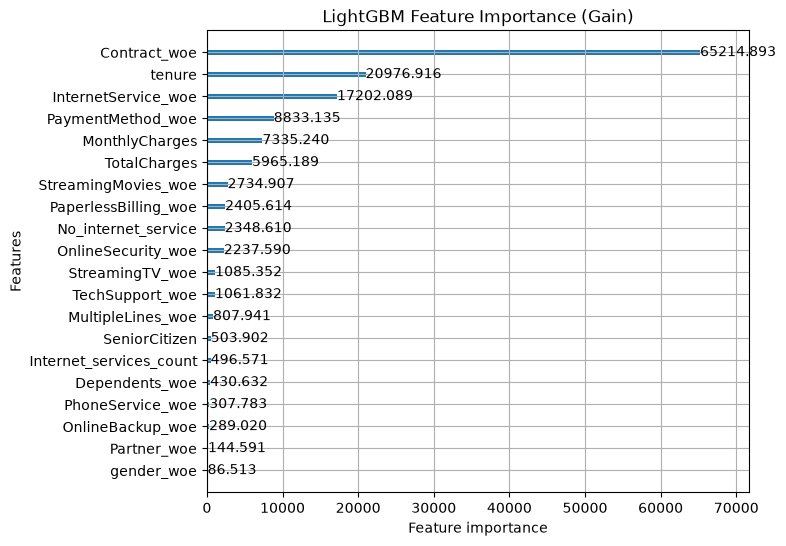

In [40]:
plot_importance(lightgbm_optimized, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show();

The gain-based feature importance shows that contract type is by far the most influential predictor, followed by customer tenure, internet service, payment method, and monthly charges.